### Naive Baseline Model

As a benchmark, we evaluate a simple trailing-window realized volatility estimate.  
Instead of forecasting future volatility, this naive model assumes that the next month's realized volatility equals the previous month's realized volatility**.

Imports

In [2]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Load Processed Volatility & Return Data

We import the pre-exported datasets created in the data-processing notebook

In [3]:
# Load future-realized volatility target for 2800.HK
df = pd.read_excel('/Users/thijsmanuel/ECON4130_Term_Paper/data/hsi_vol.xlsx').set_index('date')
hsi = df['2800.HK'] # select target column explicitly

# Load log returns for naive baseline volatility computation
log_ret = pd.read_excel('//Users/thijsmanuel/ECON4130_Term_Paper/data/hsi_log_ret.xlsx').set_index('date')

hsi, log_ret # Quick display for sanity check

(date
 2002-05-14   -3.178702
 2002-05-15   -3.173177
 2002-05-16   -3.122987
 2002-05-17   -3.165196
 2002-05-21   -3.309047
                 ...   
 2025-11-04   -2.941056
 2025-11-05   -2.930590
 2025-11-06   -3.011233
 2025-11-07   -3.003996
 2025-11-10   -3.021088
 Name: 2800.HK, Length: 5797, dtype: float64,
              2800.HK
 date                
 2002-05-14 -0.004246
 2002-05-15  0.012685
 2002-05-16  0.000000
 2002-05-17  0.012526
 2002-05-21 -0.025211
 ...              ...
 2025-12-03 -0.011499
 2025-12-04  0.007681
 2025-12-05  0.005341
 2025-12-08 -0.011481
 2025-12-09 -0.014735
 
 [5818 rows x 1 columns])

### Naive Baseline Volatility Estimation

In [4]:
# Compute naive trailing realized volatility (21-day rolling window)
back_var = log_ret['2800.HK'].pow(2).rolling(21).sum()
y_naive = 0.5 * np.log(back_var + 1e-12)  # add small constant to avoid log(0)

# Align with the true future-realized volatility target
mask = hsi.notna() & y_naive.notna()
y_true_aligned = hsi[mask]
y_naive_aligned = y_naive[mask]

# Evaluate only in the designated out-of-sample period
y_naive = y_naive_aligned[y_naive_aligned.index >= '2022-01-01']
y_true = y_true_aligned[y_true_aligned.index.isin(y_naive.index)]

# Performance evaluation of baseline model
mse = mean_squared_error(y_true, y_naive)
mae = mean_absolute_error(y_true, y_naive)
r2 = r2_score(y_true, y_naive)


print(f'MSE: {mse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}')


MSE: 0.144, MAE: 0.287, R²: -0.415


### Convert Volatility Back to Annualized Percentage Units

The naive and true volatility series are currently expressed as log-realized variance.
To make the evaluation interpretable, we convert them to annualized volatility percentages.

In [5]:
# exp() reverses the log; sqrt(12) annualizes monthly volatility; ×100 yields %
ann_true = np.exp(y_true) * np.sqrt(12) * 100
ann_pred = np.exp(y_naive) * np.sqrt(12) * 100

# Ensure OOS alignment remains intact
ann_true = ann_true[ann_true.index >= '2022-01-01']
ann_pred = ann_pred[ann_pred.index.isin(ann_true.index)]

### Visualizing Naive vs. True Annualized Volatility

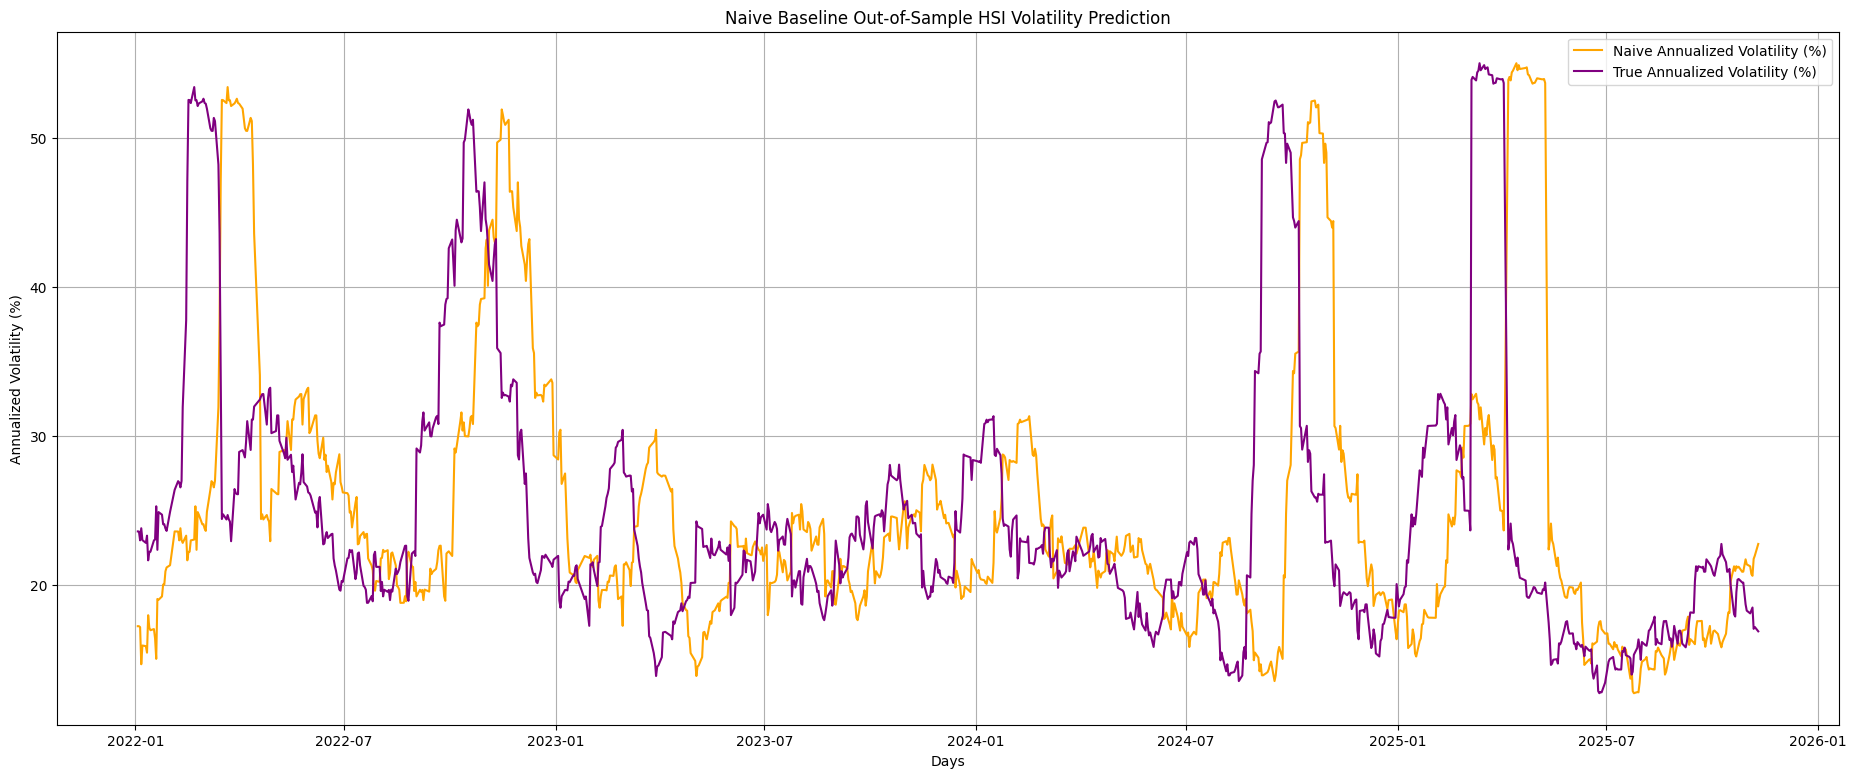

In [6]:
plt.figure(figsize=(23,9))
plt.plot(ann_pred, label='Naive Annualized Volatility (%)', c='orange') #CUHK Colors
plt.plot(ann_true, label='True Annualized Volatility (%)', c='purple') #CUHK Colors
plt.title('Naive Baseline Out-of-Sample HSI Volatility Prediction')
plt.xlabel('Days')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid()